# Bölüm 1 — Keşifsel Veri Analizi ve İstatistik

**Proje:** GPT Eklenti Ekosisteminde Gizlilik Riski Analizi ve Otomatik Sınıflandırma

**Bu bölümde:**
- Veri setinin temel yapısını inceleyeceğiz (satır/sütun sayısı, eksik veriler, tipler)
- Kategori dağılımlarını görselleştireceğiz
- **Araştırma Sorusu 1:** GPT eklentilerinin istediği veriler kategorilere nasıl dağılıyor, hassas kategoriler toplamın ne kadarını oluşturuyor?
- **Araştırma Sorusu 2:** Hassas kategorilerde açıklama (description) yazılma oranı, hassas olmayanlara göre farklı mı? (istatistiksel test)

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

DATA_PATH = '../backend/data/data_entries_final.json'

with open(DATA_PATH, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

df = pd.DataFrame(raw_data)
df.shape

(12811, 6)

## Adım 2 — Veri Yapısını İnceleme

Veriyi yükledik ama içeriğine henüz bakmadık. Bu adımda üç şeye bakıyoruz:

1. **Sütun tipleri** — `plugin_id_filenames` bir liste sütunu, diğerleri metin. Pandas bunları doğru okumuş mu kontrol ediyoruz.
2. **Eksik veriler** — özellikle `description` sütununda kaç kayıt boş bırakılmış? Bu, Araştırma Sorusu 2 için (hassas/hassas olmayan kategorilerde açıklama yazma oranı) referans noktamız olacak.
3. **Örnek satırlar** — verinin gerçekte nasıl göründüğünü gözle görmek, sayılara güvenmeden önce sağlama yapmak için.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12811 entries, 0 to 12810
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   index                12811 non-null  int64 
 1   plugin_id_filenames  12811 non-null  object
 2   name                 12811 non-null  str   
 3   description          12811 non-null  str   
 4   main_data_type       12811 non-null  str   
 5   data_type            12811 non-null  str   
dtypes: int64(1), object(1), str(4)
memory usage: 600.6+ KB


Dikkat: `description` gibi metin sütunlarında "eksik veri" genelde `NaN` değil, **boş string (`""`)** olarak saklanır. Bu yüzden sadece `.isna()` ile kontrol etmek yanıltıcı olur — boş string'leri de ayrıca sayıyoruz.

In [3]:
text_cols = ['name', 'description', 'main_data_type', 'data_type']

missing_summary = pd.DataFrame({
    'null_count': df[text_cols].isna().sum(),
    'empty_string_count': (df[text_cols] == '').sum(),
})
missing_summary['effectively_missing'] = missing_summary['null_count'] + missing_summary['empty_string_count']
missing_summary['pct_missing'] = (missing_summary['effectively_missing'] / len(df) * 100).round(2)
missing_summary

,null_count,empty_string_count,effectively_missing,pct_missing
name,0,1,1,0.01
description,0,1999,1999,15.60
main_data_type,0,0,0,0.00
data_type,0,0,0,0.00


In [4]:
df.sample(5, random_state=42)

,index,plugin_id_filenames,name,description,main_data_type,data_type
772,772,[g-2Eo3NxuS7_DX9y1883rIre0QLOgDFhKZit],files,List of files to include in the Repl.,Files and documents,File list
10196,10196,[g-nU9eHhPrc_gzm_cnf_XgzC7h8mvJI9f4uI9IAghnGS~...,chunks,Splits patterns or html into the amount of chu...,App usage data,Current session setting
385,385,"[g-009xFjOLC_OoDqO0qGP1tw2zGRYCYIfpUK, g-2UZly...",user_email,Email of the user. Has to be a real active ema...,Personal information,Email address
4269,4269,[g-GN0Zq0iZP_gzm_cnf_GpnRX0zniTgU24lIsjHtynV1~...,identifiers,"Filter by identifiers, comma-separated",Identifier,Resource IDs
8,8,[g-dnFnjifmN_gzm_cnf_JriSWBp4x1f0ITBun22ZIjjq~...,num_results,How many results to return. Defaults to 5. It ...,App usage data,Current session setting


## Adım 3 — Kategori Dağılımları (Araştırma Sorusu 1)

`main_data_type` sütununda 25 farklı kategori var. Önce hepsinin sayısına bakıp hangi kategorilerin veri setine hakim olduğunu, hangilerinin nadir kaldığını göreceğiz (kuyruğun ne kadar uzun olduğu, kümeleme ve modelleme adımlarında da işimize yarayacak).

Sonra asıl soruya geliyoruz: **"hassas" kategoriler** — `Security credentials`, `Personal information`, `Health information`, `Finance information` — toplam verinin ne kadarını oluşturuyor? Bunu hem sayı hem yüzde olarak çıkaracağız, hem de tek bir grafikte görselleştireceğiz (hassas kategorileri kırmızıyla, geri kalanını nötr gri ile işaretleyerek).

In [5]:
category_counts = df['main_data_type'].value_counts()
category_pct = (category_counts / len(df) * 100).round(2)

category_table = pd.DataFrame({'count': category_counts, 'pct': category_pct})
category_table

,count,pct
main_data_type,,
App usage data,2568,20.05
Identifier,1888,14.74
Other,1721,13.43
Query,1416,11.05
Time,1131,8.83
Web and network data,925,7.22
Location,701,5.47
Personal information,435,3.40
Files and documents,412,3.22


In [6]:
SENSITIVE_CATEGORIES = [
    'Security credentials',
    'Personal information',
    'Health information',
    'Finance information',
]

df['is_sensitive'] = df['main_data_type'].isin(SENSITIVE_CATEGORIES)

sensitive_summary = df['is_sensitive'].value_counts().rename({True: 'Hassas', False: 'Hassas değil'})
sensitive_pct = (sensitive_summary / len(df) * 100).round(2)

print(pd.DataFrame({'count': sensitive_summary, 'pct': sensitive_pct}))
print()
print('Hassas kategorilerin kırılımı:')
print(category_table.loc[SENSITIVE_CATEGORIES])

              count    pct
is_sensitive              
Hassas değil  11880  92.73
Hassas          931   7.27

Hassas kategorilerin kırılımı:
                      count   pct
main_data_type                   
Security credentials    276  2.15
Personal information    435  3.40
Health information       82  0.64
Finance information     138  1.08


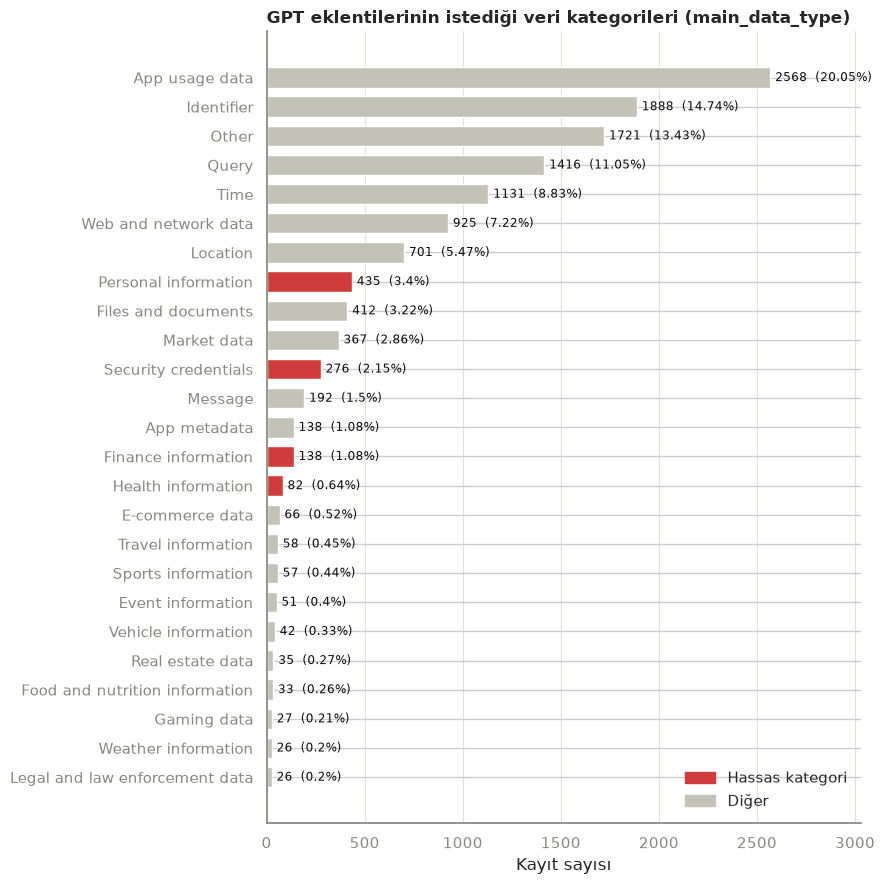

In [7]:
COLOR_SENSITIVE = '#d03b3b'
COLOR_NEUTRAL = '#c3c2b7'
COLOR_TEXT = '#0b0b0b'
COLOR_MUTED = '#898781'

ordered = category_table.sort_values('count', ascending=True)
colors = [COLOR_SENSITIVE if cat in SENSITIVE_CATEGORIES else COLOR_NEUTRAL for cat in ordered.index]

fig, ax = plt.subplots(figsize=(9, 9))
bars = ax.barh(ordered.index, ordered['count'], color=colors, height=0.7)

for bar, count, pct in zip(bars, ordered['count'], ordered['pct']):
    ax.text(bar.get_width() + 25, bar.get_y() + bar.get_height() / 2,
            f'{count}  ({pct}%)', va='center', ha='left', fontsize=8.5, color=COLOR_TEXT)

ax.set_xlabel('Kayıt sayısı')
ax.set_title('GPT eklentilerinin istediği veri kategorileri (main_data_type)', loc='left', fontsize=12, fontweight='bold')
ax.set_xlim(0, ordered['count'].max() * 1.18)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(COLOR_MUTED)
ax.tick_params(colors=COLOR_MUTED)
ax.grid(axis='x', color='#e1e0d9', linewidth=0.8)
ax.set_axisbelow(True)

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=COLOR_SENSITIVE, label='Hassas kategori'),
    plt.Rectangle((0, 0), 1, 1, color=COLOR_NEUTRAL, label='Diğer'),
]
ax.legend(handles=legend_handles, loc='lower right', frameon=False)

plt.tight_layout()

import os
os.makedirs('exported_charts', exist_ok=True)
plt.savefig('exported_charts/rq1_category_distribution.png', dpi=150, bbox_inches='tight')

plt.show()

### Bulgu (Araştırma Sorusu 1)

Grafikten görüldüğü gibi dağılım oldukça çarpık: en büyük üç kategori (`App usage data`, `Identifier`, `Other`) tek başına verinin yaklaşık yarısını oluşturuyor, geri kalan 22 kategori ise uzun bir kuyruk halinde küçülerek devam ediyor.

Aşağıda tanımladığımız dört hassas kategorinin (`Security credentials`, `Personal information`, `Health information`, `Finance information`) toplam içindeki payını net bir cümleyle özetliyoruz.

In [8]:
n_sensitive = int(df['is_sensitive'].sum())
pct_sensitive = round(n_sensitive / len(df) * 100, 1)

top3 = category_counts.head(3)
pct_top3 = round(top3.sum() / len(df) * 100, 1)

print(f"En büyük 3 kategori ({', '.join(top3.index)}) toplamın %{pct_top3}'ini oluşturuyor.")
print(f"4 hassas kategori (Security credentials, Personal information, Health information, Finance information) "
      f"toplam {n_sensitive} kayıtla verinin %{pct_sensitive}'ini oluşturuyor.")

En büyük 3 kategori (App usage data, Identifier, Other) toplamın %48.2'ini oluşturuyor.
4 hassas kategori (Security credentials, Personal information, Health information, Finance information) toplam 931 kayıtla verinin %7.3'ini oluşturuyor.


## Adım 4 — Açıklama Yazma Oranı: Hassas vs. Hassas Değil (Araştırma Sorusu 2)

Sezgisel olarak beklenebilir ki bir parametre hassas bir veri istiyorsa (örn. bir şifre ya da sağlık bilgisi), geliştirici bunu daha özenle açıklasın — kullanıcıya ne için istendiğini net anlatsın. Burada bunu test ediyoruz: **hassas kategorilerdeki parametrelerin açıklaması olma oranı, hassas olmayanlardan gerçekten farklı mı, yoksa gördüğümüz fark rastgele dalgalanmadan mı ibaret?**

Adım 2'de `description` için boşluğun `NaN` değil boş string olduğunu görmüştük; onu burada da aynı şekilde kullanıyoruz. İki kategorik değişkenimiz var (hassas mı / açıklaması var mı), bu yüzden uygun test **ki-kare (chi-square) bağımsızlık testi** — iki kategorik değişken arasında ilişki var mı diye bakar. Sadece p-değerine değil, farkın pratikte ne kadar büyük olduğuna (Cramér's V ile) de bakacağız; çünkü 12.811 gibi büyük bir örneklemde çok küçük farklar bile istatistiksel olarak "anlamlı" çıkabilir.

In [9]:
df['has_description'] = df['description'] != ''

contingency = pd.crosstab(df['is_sensitive'], df['has_description'])
contingency.index = contingency.index.map({True: 'Hassas', False: 'Hassas değil'})
contingency.columns = contingency.columns.map({True: 'Açıklama var', False: 'Açıklama yok'})
contingency

has_description,Açıklama yok,Açıklama var
is_sensitive,,
Hassas değil,1824,10056
Hassas,175,756


In [10]:
contingency_pct = (contingency.div(contingency.sum(axis=1), axis=0) * 100).round(2)
contingency_pct

has_description,Açıklama yok,Açıklama var
is_sensitive,,
Hassas değil,15.35,84.65
Hassas,18.80,81.20


In [11]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(contingency)

n = contingency.values.sum()
k = min(contingency.shape) - 1
cramers_v = np.sqrt(chi2 / (n * k))

print(f'Chi-square istatistiği: {chi2:.3f}')
print(f'p-değeri: {p_value:.4f}')
print(f'Serbestlik derecesi: {dof}')
print(f"Cramér's V (etki büyüklüğü): {cramers_v:.4f}")

Chi-square istatistiği: 7.514
p-değeri: 0.0061
Serbestlik derecesi: 1
Cramér's V (etki büyüklüğü): 0.0242


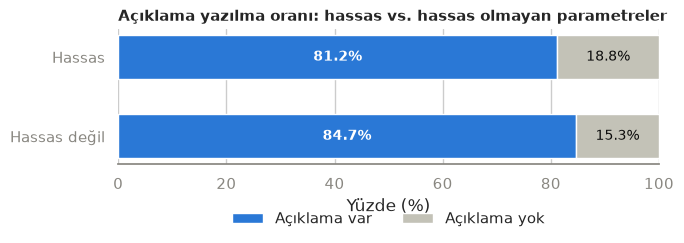

In [12]:
COLOR_HAS_DESC = '#2a78d6'
COLOR_NO_DESC = '#c3c2b7'

groups = contingency_pct.index.tolist()
has_desc_pct = contingency_pct['Açıklama var']
no_desc_pct = contingency_pct['Açıklama yok']

fig, ax = plt.subplots(figsize=(7, 2.8))
ax.barh(groups, has_desc_pct, color=COLOR_HAS_DESC, height=0.55, label='Açıklama var')
ax.barh(groups, no_desc_pct, left=has_desc_pct, color=COLOR_NO_DESC, height=0.55, label='Açıklama yok')

for i, group in enumerate(groups):
    ax.text(has_desc_pct[group] / 2, i, f'{has_desc_pct[group]:.1f}%',
            va='center', ha='center', fontsize=10, color='white', fontweight='bold')
    ax.text(has_desc_pct[group] + no_desc_pct[group] / 2, i, f'{no_desc_pct[group]:.1f}%',
            va='center', ha='center', fontsize=10, color=COLOR_TEXT)

ax.set_xlim(0, 100)
ax.set_xlabel('Yüzde (%)')
ax.set_title('Açıklama yazılma oranı: hassas vs. hassas olmayan parametreler', loc='left', fontsize=11, fontweight='bold')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(COLOR_MUTED)
ax.tick_params(colors=COLOR_MUTED, left=False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2, frameon=False)

plt.tight_layout()

import os
os.makedirs('exported_charts', exist_ok=True)
plt.savefig('exported_charts/rq2_description_rate.png', dpi=150, bbox_inches='tight')

plt.show()

### Bulgu (Araştırma Sorusu 2)

Sonuç, sezgimizin **tersi** çıktı: hassas kategorilerdeki parametrelerde açıklama yazılma oranı (%81.2), hassas olmayanlara göre (%84.65) biraz daha **düşük** — yani geliştiriciler hassas veri isteyen parametreleri daha az açıklıyor, daha çok değil.

Ki-kare testi bu farkın rastgele olmadığını söylüyor (p ≈ 0.006, %5 anlamlılık eşiğinin altında), yani istatistiksel olarak anlamlı bir ilişki var. Ama Cramér's V ≈ 0.024 — bu, iki değişken arasındaki ilişkinin **pratikte çok zayıf** olduğu anlamına geliyor. Kısacası: 12.811 kayıtlık büyük örneklem sayesinde küçücük bir fark bile "istatistiksel olarak anlamlı" çıkabiliyor, ama bu farkın gerçek dünyada önemli bir etkisi yok denecek kadar küçük. Pratik sonuç: **hassas/hassas değil ayrımı, bir parametrenin açıklamasının olup olmayacağını neredeyse hiç öngörmüyor** — description eksikliği kategoriden bağımsız, genel bir alışkanlık gibi görünüyor.

## Özet — Bölüm 1

**Veri seti:** 12.811 parametre kaydı, 6 sütun. `name` ve `main_data_type`/`data_type` neredeyse hiç boş değil; `description` kayıtların **%15.6**'sında boş (1.999 kayıt) — bu, ileride metin tabanlı sınıflandırma yaparken (Bölüm 2) elimizdeki metin sinyalinin bir kısmının zayıf olacağı anlamına geliyor.

**Araştırma Sorusu 1 — Kategori dağılımı:**
- `main_data_type` çarpık bir dağılıma sahip: en büyük 3 kategori (`App usage data`, `Identifier`, `Other`) verinin **%48.2**'sini kaplıyor.
- Hassas kategoriler (`Security credentials`, `Personal information`, `Health information`, `Finance information`) toplamda **931 kayıt (%7.3)** — küçük ama önemli bir dilim; özellikle "Security credentials" ve "Personal information" GPT eklentilerinin görece sık istediği hassas veri türleri.

**Araştırma Sorusu 2 — Açıklama yazma oranı:**
- Hassas kategorilerde açıklama yazılma oranı (%81.2), hassas olmayanlara göre (%84.65) hafifçe **daha düşük** — beklentinin tersi bir yön.
- Ki-kare testi bu farkı istatistiksel olarak anlamlı buluyor (p ≈ 0.006), ama etki büyüklüğü (Cramér's V ≈ 0.024) ihmal edilebilir düzeyde küçük. Yani hassasiyet, bir parametrenin açıklamasının olup olmayacağını pratikte neredeyse hiç öngörmüyor.

**Bölüm 2'ye taşınacak notlar:**
- `data_type` sütununda 145 farklı değer var ve dağılım son derece uzun kuyruklu (medyan sınıf boyutu 11, 6 sınıfta tek bir kayıt bile var). Bu, metin sınıflandırma modelini kurarken hangi hedef sütunu (`main_data_type` mi `data_type` mi) kullanacağımızı ve nadir sınıfları nasıl ele alacağımızı dikkatlice seçmemiz gerektiği anlamına geliyor.